In this notebook I'll do the training part.
1. Load the prepared GRU training and testing arrays
2. Build the GRU neural network
3. Handle class imbalance using class weights
4. Train the model using validation data
5. Apply early stopping to reduce overfitting
6. Save the trained GRU model and training history

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.0


In [4]:
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.1


In [5]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Random seeds configured successfully.")

Random seeds configured successfully.


In [6]:
PROJECT_ROOT = os.path.abspath("..")

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)

Project root: d:\SMS_Spam_Detection
Models directory: d:\SMS_Spam_Detection\models
Results directory: d:\SMS_Spam_Detection\results


In [7]:
print("Files inside models folder:")

for filename in os.listdir(MODELS_DIR):
    print("-", filename)

Files inside models folder:
- final_gru_model.keras
- gru_sequence_config.json
- gru_spam_model.keras
- gru_tokenizer.json
- svm_model.pkl
- tfidf_vectorizer.pkl
- X_test_padded.npy
- X_train_padded.npy
- y_test_gru.npy
- y_train_gru.npy


In [8]:
config_path = os.path.join(MODELS_DIR, "gru_sequence_config.json")

with open(config_path, "r", encoding="utf-8") as file:
    gru_config = json.load(file)

print("GRU configuration:")
print(gru_config)

GRU configuration:
{'max_words': 10000, 'vocab_size': 6824, 'max_length': 33, 'padding': 'post', 'truncating': 'post', 'oov_token': '<OOV>'}


In [9]:
{
    "vocab_size": 6824,
    "max_length": 33
}

{'vocab_size': 6824, 'max_length': 33}

In [10]:
X_train_padded = np.load(
    os.path.join(MODELS_DIR, "X_train_padded.npy")
)

X_test_padded = np.load(
    os.path.join(MODELS_DIR, "X_test_padded.npy")
)

y_train = np.load(
    os.path.join(MODELS_DIR, "y_train_gru.npy")
)

y_test = np.load(
    os.path.join(MODELS_DIR, "y_test_gru.npy")
)

print("Arrays loaded successfully.")

Arrays loaded successfully.


In [11]:
print("X_train shape:", X_train_padded.shape)
print("X_test shape:", X_test_padded.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4035, 33)
X_test shape: (1009, 33)
y_train shape: (4035,)
y_test shape: (1009,)


In [12]:
print("X_train shape:", X_train_padded.shape)
print("X_test shape:", X_test_padded.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nUnique training labels:", np.unique(y_train))
print("Unique testing labels:", np.unique(y_test))

X_train shape: (4035, 33)
X_test shape: (1009, 33)
y_train shape: (4035,)
y_test shape: (1009,)

Unique training labels: [0 1]
Unique testing labels: [0 1]


In [13]:
vocab_size = gru_config["vocab_size"]
max_length = gru_config["max_length"]

input_dimension = vocab_size + 1

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_length)
print("Embedding input dimension:", input_dimension)

Vocabulary size: 6824
Max sequence length: 33
Embedding input dimension: 6825


In [14]:
unique_classes, class_counts = np.unique(
    y_train,
    return_counts=True
)

for class_label, count in zip(unique_classes, class_counts):
    class_name = "Ham" if class_label == 0 else "Spam"
    print(f"{class_name}: {count}")

Ham: 3572
Spam: 463


In [15]:
classes = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_label): float(weight)
    for class_label, weight in zip(classes, class_weight_values)
}

print("Class weights:", class_weights)

Class weights: {0: 0.5648096304591266, 1: 4.357451403887689}


In [16]:
EMBEDDING_DIM = 64
GRU_UNITS = 64
DROPOUT_RATE = 0.3

print("Embedding dimension:", EMBEDDING_DIM)
print("GRU units:", GRU_UNITS)
print("Dropout rate:", DROPOUT_RATE)

Embedding dimension: 64
GRU units: 64
Dropout rate: 0.3


In [17]:
gru_model = Sequential([
    Embedding(
        input_dim=input_dimension,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding_layer"
    ),

    SpatialDropout1D(
        DROPOUT_RATE,
        name="spatial_dropout"
    ),

    GRU(
        units=GRU_UNITS,
        dropout=0.2,
        name="gru_layer"
    ),

    Dropout(
        DROPOUT_RATE,
        name="dropout_layer"
    ),

    Dense(
        units=32,
        activation="relu",
        name="dense_layer"
    ),

    Dropout(
        0.2,
        name="dense_dropout"
    ),

    Dense(
        units=1,
        activation="sigmoid",
        name="output_layer"
    )
])

print("GRU model created.")

GRU model created.


In [18]:
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("GRU model compiled")

GRU model compiled


In [19]:
gru_model.build(
    input_shape=(None, max_length)
)

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 33, 64)         │       436,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 33, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,873 (1.77 MB)

 Trainable params: 463,873 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
best_model_path = os.path.join(
    MODELS_DIR,
    "best_gru_model.keras"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_learning_rate
]

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


In [21]:
EPOCHS = 15
BATCH_SIZE = 32

history = gru_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8203 - auc: 0.8538 - loss: 0.5262 - precision: 0.3571 - recall: 0.6782
Epoch 1: val_loss improved from None to 0.17907, saving model to d:\SMS_Spam_Detection\models\final_gru_model.keras

Epoch 1: finished saving model to d:\SMS_Spam_Detection\models\final_gru_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8203 - auc: 0.8538 - loss: 0.5262 - precision: 0.3571 - recall: 0.6782 - val_accuracy: 0.9591 - val_auc: 0.9874 - val_loss: 0.1791 - val_precision: 0.7368 - val_recall: 0.9655 - learning_rate: 0.0010
Epoch 2/15
100/101 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9747 - auc: 0.9867 - loss: 0.1148 - precision: 0.8415 - recall: 0.9652
Epoch 2: val_loss improved from 0.17907 to 0.10949, saving model to d:\SMS_Spam_Detection\models\final_gru_model.keras

Epoch 2: finished saving model to d:\SMS_Spam_Detection\models\final_gru_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9749 

In [22]:
final_model_path = os.path.join(
    MODELS_DIR,
    "gru_spam_model.keras"
)

gru_model.save(final_model_path)

print("Final GRU model saved.")
print("Saved at:", final_model_path)

Final GRU model saved.
Saved at: d:\SMS_Spam_Detection\models\gru_spam_model.keras


In [23]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.820322,0.853753,0.526213,0.357143,0.678191,0.959108,0.987436,0.179067,0.736842,0.965517,0.0010
1,0.974907,0.986795,0.114017,0.842227,0.965426,0.972739,0.989950,0.109494,0.815534,0.965517,0.0010
2,0.989467,0.995681,0.057131,0.936224,0.976064,0.980173,0.990054,0.073838,0.873684,0.954023,0.0010
3,0.996592,0.999550,0.022267,0.979003,0.992021,0.982652,0.989033,0.057816,0.892473,0.954023,0.0010
4,0.997522,0.999758,0.014607,0.984211,0.994681,0.961586,0.986678,0.125800,0.750000,0.965517,0.0010
5,0.997831,0.999986,0.005862,0.981723,1.000000,0.982652,0.989575,0.088196,0.884211,0.965517,0.0010
6,0.998761,0.999992,0.003218,0.989474,1.000000,0.981413,0.986103,0.063579,0.891304,0.942529,0.0005


In [24]:
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

In [25]:
history_path = os.path.join(
    RESULTS_DIR,
    "gru_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("GRU training history saved now")
print("Saved at:", history_path)

GRU training history saved now
Saved at: d:\SMS_Spam_Detection\results\gru_training_history.csv


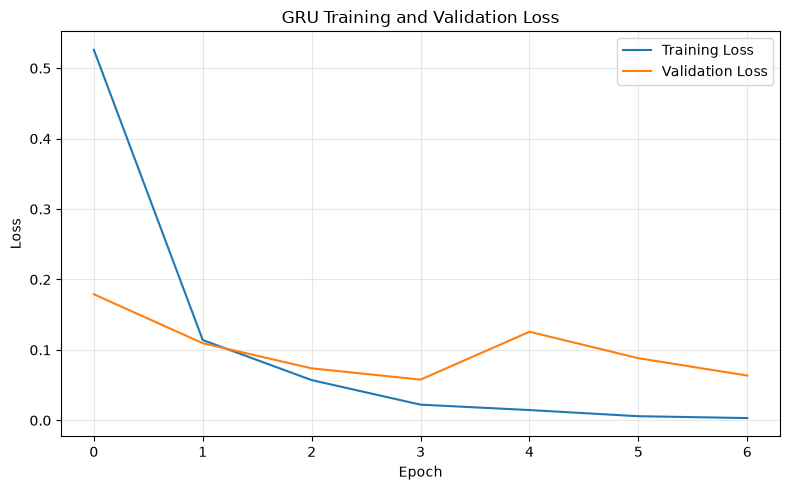

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "gru_training_validation_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

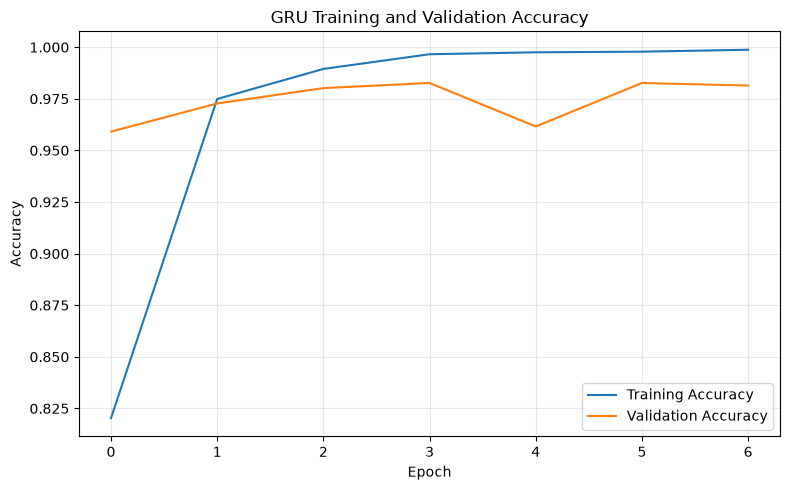

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("GRU Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "gru_training_validation_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

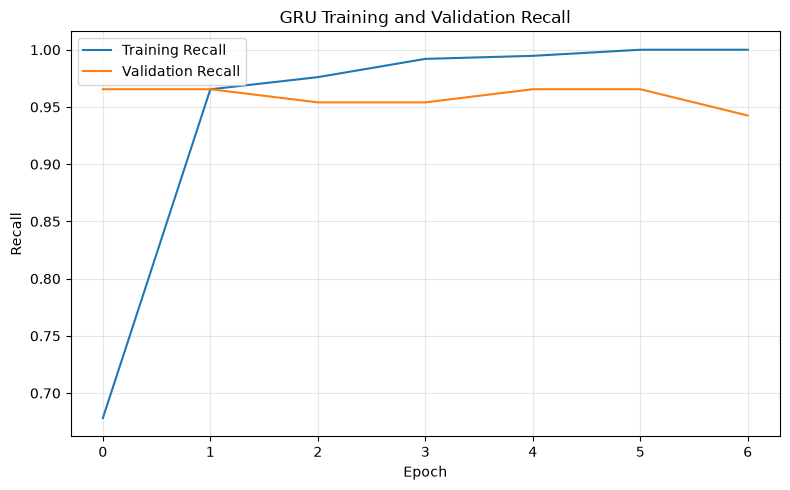

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["recall"],
    label="Training Recall"
)

plt.plot(
    history.history["val_recall"],
    label="Validation Recall"
)

plt.title("GRU Training and Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "gru_training_validation_recall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
best_epoch = np.argmin(
    history.history["val_loss"]
) + 1

print("Completed epochs:", len(history.history["loss"]))
print("Best epoch:", best_epoch)
print(
    "Lowest valid. loss:",
    round(min(history.history["val_loss"]), 4)
)
print(
    "Highest valid. accuracy:",
    round(max(history.history["val_accuracy"]), 4)
)
print(
    "Highest valid. recall:",
    round(max(history.history["val_recall"]), 4)
)

Completed epochs: 7
Best epoch: 4
Lowest valid. loss: 0.0578
Highest valid. accuracy: 0.9827
Highest valid. recall: 0.9655


In [30]:
print(
    "Best model saved:",
    os.path.exists(best_model_path)
)

print(
    "Final model saved:",
    os.path.exists(final_model_path)
)

print(
    "Saved training history:",
    os.path.exists(history_path)
)

Best model saved: True
Final model saved: True
Saved training history: True


DL model (GRU) trained and developed successfully.